# Task:

    1. Define new training preparation based on TransfomrerCPDNewView
    2. Train and Test model

# Import libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm
from IPython.display import clear_output
from sklearn.preprocessing import normalize
from sklearn.preprocessing import scale

In [2]:
import sys

sys.path.append("../..")

In [3]:
from src.data.SythData import SimpleRandomTimeSeries
from src.models.SubspaceBased.SingularSequenceTransformer import SingularSequenceTransformer

# Define parameters

In [4]:
padding_val = -9999
max_sequence_len = 1024
sequence_chunk = 32
n_head = 4

# Define Neural Network

In [5]:
class TransformerCPD(nn.Module):
    def __init__(self,
                 sequence_length: int = 42,
                 n_layers: int = 6,
                 n_heads: int = 6,
                 dim_feedforward: int = 2048):
        super().__init__()
        
        self.activation = nn.LeakyReLU()
        self.linear = nn.Linear(420, 1)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=sequence_length,
                                                   nhead=n_heads,
                                                   dim_feedforward=dim_feedforward,
                                                   norm_first=True,
                                                   batch_first=True)
        decoder_layer = nn.TransformerDecoderLayer(d_model=sequence_length,
                                                   nhead=n_heads,
                                                   dim_feedforward=dim_feedforward,
                                                   norm_first=True,
                                                   batch_first=True)
        
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

    @torch.inference_mode()
    def encode(self, x):
        """ Encode time series to a map of features.

        Arg:
            x: batch of raw time series data.
            
        Return:
            batch of encoded time series data.
        """
        return self.encoder(x)

    def forward(self, encoder_x, decoder_x):
        encoded_data = self.encoder(src=encoder_x)
                                    #src_key_padding_mask=encoder_pad_mask)
        decoded_data = self.decoder(memory=encoded_data,
                                   # memory_key_padding_mask=encoder_pad_mask,
                                    tgt=decoder_x
                                   # tgt_key_padding_mask=decoder_pad_mask
                                   )
        out = self.linear(self.activation(decoded_data.view(decoded_data.shape[0], 420)))
        return out

# Help Functions

2. **Padding Mask Purpose**:
   - The mask identifies which positions in the sequence (of length 32) are padding tokens for each batch item.
   - Shape starts as `(batch_size, seq_len)`.

3. **Mask Size**:
   - If `batch_size = 16` (each word as a batch item) and `seq_len = 32`:
     - Initial mask size: `(16, 32)`.
     - 0s for real tokens, 1s for padding (or vice versa, depending on your convention).
   - In attention, scores are `(batch_size, num_heads, seq_len, seq_len)` = `(16, num_heads, 32, 32)`.
     - Mask is reshaped to `(16, 1, 1, 32)` or broadcasted to `(16, num_heads, 32, 32)`.
     
 
### Final Answer
- **Correct `x_mask_padding` Size**: `(1, 6)` for `(batch_size, seq_len)`.
- Transform your `(6, 32)` mask to `(1, 6)` by reducing across features (e.g., `mask.all(dim=1).unsqueeze(0)`).

# Define DataClass

In [6]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=1024, device: str = "cuda"):
        """ 
        Notes:
            d_model: number of features which reprsenet 1 token in NLP.
            max_len: length of the longest sequence which we can hold in memory by POSINCODING!
        
        Example:
            max_len 1024 means that max pos len is 1024 for time series which has 16 sequence where 
            each sequence length is 32. Like torch.Size([16, 1, 32]) # number sequences, batch, feature sequence
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1).to(torch.device(device))
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x

In [7]:
from torch.utils.data import Dataset

class TimeSeries(Dataset):
    def __init__(self, time_series, sequence_length_nn: int = 42):
        self.time_series = time_series
        self.sequence_length_nn = sequence_length_nn
    
    def padding_sequence(self, data: np.array, d_model: int) -> np.array:
        not_dev_count = data.shape[0] % d_model
        if not_dev_count != 0:
            val_new_rows = int(np.ceil(data.shape[0] / d_model) * d_model - data.shape[0])
            data = np.pad(data, 
                     pad_width=((0), (val_new_rows)),  # Pad val_new_rows to sequence
                     mode='constant', 
                     constant_values=data[-1])
        return data
    
    def prepaire_sequence_to_encoding(self, data) -> torch.Tensor:
        """ Take padded numpy array to preapre it to torch.Tensor for NN
        """
        # aka time series points in one word
        number_of_words = data.shape[0] // self.sequence_length_nn
        return torch.Tensor(data).view(number_of_words, self.sequence_length_nn)
    
    def get_decoder_features(self, data: np.array) -> np.array:
        sst = SingularSequenceTransformer(n_components=2,
                                          sequence_window=32,
                                          lag=5,
                                          queue_window=10,
                                          is_fast_parameter_selection=False).fit(x_train=data, y_train=None)
        return sst.get_distances(target_array=data)
    
#     def normalize_by_mean(self, data: np.array) -> np.array:
#         mean = data.mean()
#         std = data.std()
#         return (data - mean) / std
    def normalize_by_minmax(self, data: np.array) -> np.array:
        return (data-data.min())/(data.max()-data.min())
    

    def __getitem__(self, idx):
        y, x = self.time_series[idx]
        x_sst = self.get_decoder_features(x)
        
        x = self.normalize_by_minmax(x)
        x_sst = self.normalize_by_minmax(x_sst)
        padded_x = self.padding_sequence(x, d_model=self.sequence_length_nn)
        padded_sst = self.padding_sequence(x_sst, d_model=self.sequence_length_nn)
#         padded_y = self.padding_sequence(y, d_model=self.sequence_length_nn)
        
        x_prepaired = self.prepaire_sequence_to_encoding(padded_x)
        sst_prepaired = self.prepaire_sequence_to_encoding(padded_sst)
#         y_prepaired = self.prepaire_sequence_to_encoding(padded_y)
        return torch.Tensor(x_prepaired), torch.Tensor(sst_prepaired), torch.Tensor([sum(y)])

    def __len__(self):
        return len(self.time_series)

In [8]:
import random

def add_probs_near_changepoint(cps: list):
    cps_new = []
    for index, val in enumerate(cps):
        cps_new.append(val)
        if val == 1:
            cps_new[index-1] = 0.85
            cps_new[index-2] = 0.7
            cps_new[index-3] = 0.5
            cps_new[index-4] = 0.3
            cps_new[index-5] = 0.1
            cps_new[index-6] = 1e-2
            cps_new[index-7] = 1e-3
        
    return np.array(cps_new)
        
def generate_some_training_data(number_datasets=1000,
                                cps_number_list=[9, 10, 11, 12, 13,14, 15],
                                length_data_list=[400],
                                min_max_std_list=[1, 5, 50, 100],
                                min_max_val_list=[5, 50, 100]) -> list:
    time_series = []
    for val in range(number_datasets):
        tmp_cps = random.choice(cps_number_list)
        tmp_length = random.choice(length_data_list)
        tmp_std = random.choice(min_max_std_list)
        tmp_val = random.choice(min_max_val_list)
        data_obj = SimpleRandomTimeSeries(length_data=tmp_length, cps_number=tmp_cps)
        y, x = data_obj.get(min_max_std=tmp_std, min_max_val=tmp_val)
#         y = add_probs_near_changepoint(cps=y)
        time_series.append((y, x))
    return time_series

In [9]:
# define encoder positional
encoding_pos = PositionalEncoding(d_model=42)

In [10]:
time_series_train = generate_some_training_data(number_datasets=5000)
time_series_valid = generate_some_training_data(number_datasets=1000)

In [11]:
train_dataset = TimeSeries(time_series=time_series_train)
valid_dataset = TimeSeries(time_series=time_series_valid)

In [12]:
x_0, x_1, y = next(iter(train_dataset))

In [13]:
x_0.view(420)

tensor([0.5615, 0.5615, 0.5615, 0.5615, 0.5615, 0.5615, 0.5615, 0.5615, 0.5615,
        0.5615, 0.5615, 0.3529, 0.3529, 0.3529, 0.3529, 0.3529, 0.3529, 0.3529,
        0.3529, 0.3529, 0.3529, 0.3529, 0.3529, 0.3529, 0.3529, 0.3529, 0.3529,
        0.1444, 0.1444, 0.1444, 0.1444, 0.1444, 0.1444, 0.1444, 0.1444, 0.1444,
        0.1444, 0.1444, 0.1444, 0.1444, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2086, 0.2086, 0.2086, 0.2086, 0.2086, 0.2086, 0.2086, 0.2086, 0.2086,
        0.2086, 0.2086, 0.2086, 0.2086, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.1658, 0.1658,
        0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658,
        0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658, 0.1658,
        0.1658, 0.0963, 0.0963, 0.0963, 0.0963, 0.0963, 0.0963, 0.0963, 0.0963,
        0.0963, 0.0963, 0.0963, 0.0963, 

In [14]:
from torch.utils.data import DataLoader


train_loader = DataLoader(train_dataset, batch_size=64, num_workers=5, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, num_workers=5, pin_memory=True)

# Training

In [15]:
def train(model, loader):
    model.train()

    train_loss = 0

    for x_en, x_dec, y in tqdm(loader, desc='Training'):
        x_en, x_dec, y = x_en.to(device), x_dec.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(encoding_pos(x_en), encoding_pos(x_dec))

        loss = loss_fn(output, y)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_loader)

    return train_loss

In [16]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    total_loss = 0

    for x_en, x_dec, y in tqdm(loader, desc='Evaluation'):
        x_en, x_dec, y = x_en.to(device), x_dec.to(device), y.to(device)

        output = model(encoding_pos(x_en), encoding_pos(x_dec))

        loss = loss_fn(output, y)

        total_loss += loss.item()

    total_loss /= len(loader)

    return total_loss

In [17]:
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

In [18]:
def whole_train_valid_cycle(model, num_epochs, title):
    train_loss_history, valid_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader)
        valid_loss = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait=True)

        plot_stats(
            train_loss_history, valid_loss_history,
            title
        )

In [19]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

cuda:0
NVIDIA GeForce RTX 3060 Laptop GPU


In [20]:
model = TransformerCPD().to(device)

/home/gishb/PycharmProjects/DirectionalDrillingChangePointDetection/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [21]:
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=0.6, foreach=False)
loss_fn = nn.L1Loss(reduction="sum")

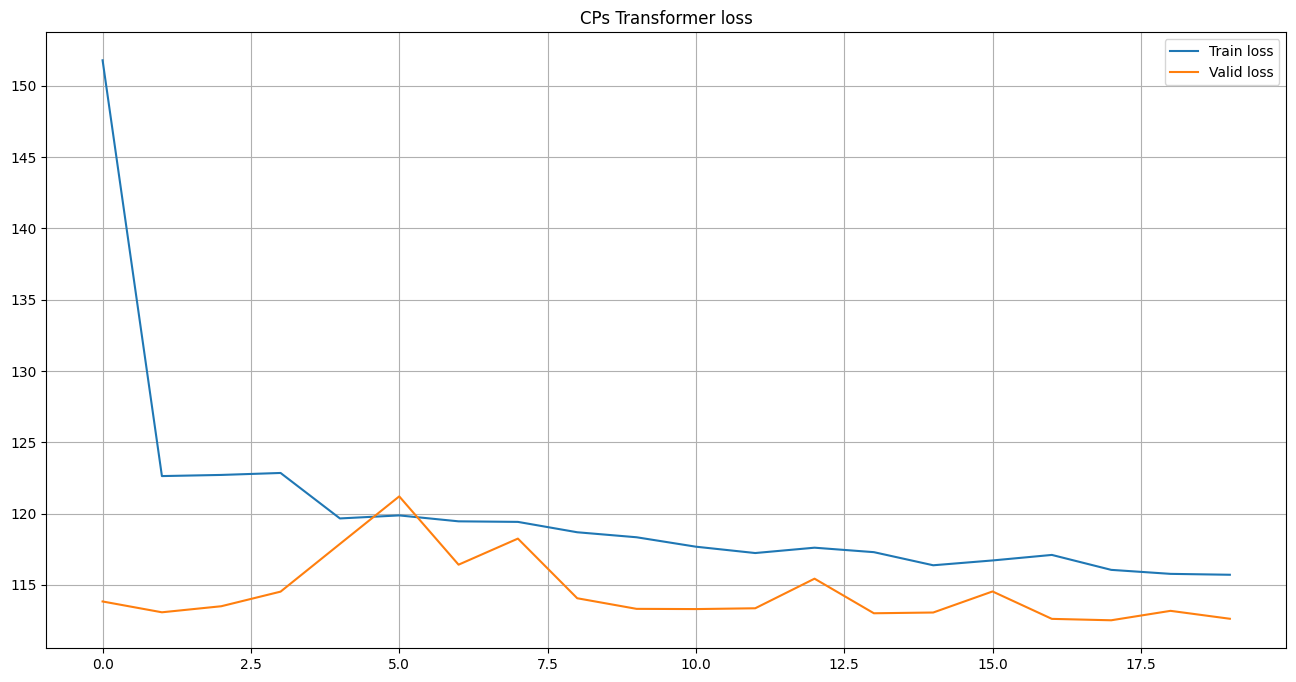

Training:  70%|████████████████████████████████████████████████████████████████████████████████                                   | 55/79 [05:51<01:19,  3.33s/it]

In [ ]:
whole_train_valid_cycle(model, 30, 'CPs Transformer')

In [ ]:
x_0, x_1, y = next(iter(train_dataset))

In [ ]:
model.eval()

In [ ]:
out = model(x_0.to(device), x_1.to(device))

In [ ]:
plt.plot(torch.sigmoid(out.view(448).to("cpu").detach()))

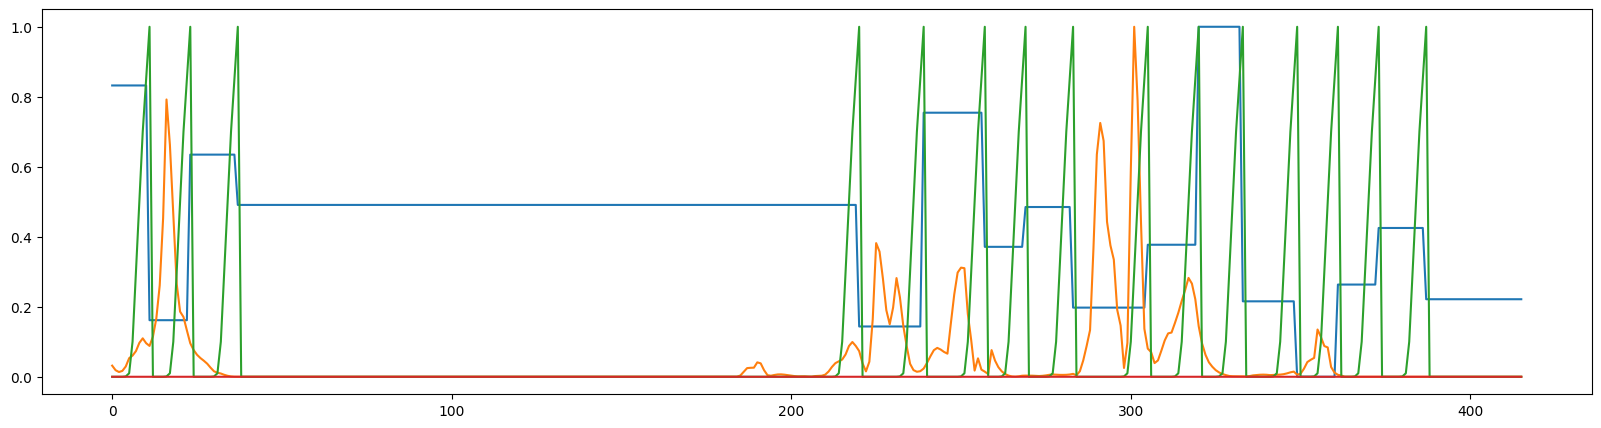

In [82]:
plt.figure(figsize=(20,5))
plt.plot(x_0.view(416))
plt.plot(x_1.view(416))
plt.plot(y.view(416))
plt.plot(torch.sigmoid(out.view(416).to("cpu").detach()))